<a href="https://colab.research.google.com/github/rosimeireferreiradasilva819-ui/PwebII/blob/main/AprendizadoN%C3%A3oSupervisionadoipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.metrics import silhouette_score

iris = load_iris()
df = pd.DataFrame(iris.data, columns=['Comp_Sepala', 'Larg_Sepala', 'Comp_Petala', 'Larg_Petala'])

print(f"Dataset carregado: {df.shape[0]} amostras e {df.shape[1]} atributos.")
display(df.describe())

Dataset carregado: 150 amostras e 4 atributos.


,Comp_Sepala,Larg_Sepala,Comp_Petala,Larg_Petala
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


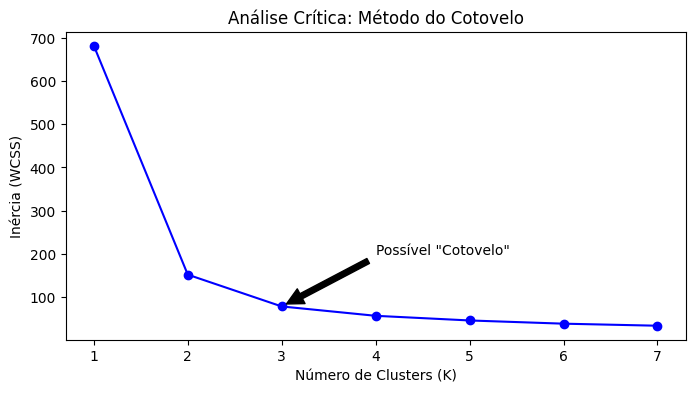

In [8]:
inercias = []
K_range = range(1, 8)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(df)
    inercias.append(model.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inercias, 'bo-')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inércia (WCSS)')
plt.title('Análise Crítica: Método do Cotovelo')
plt.annotate('Possível "Cotovelo"', xy=(3, inercias[2]), xytext=(4, 200),
             arrowprops=dict(facecolor='black', shrink=0.05))
plt.show()

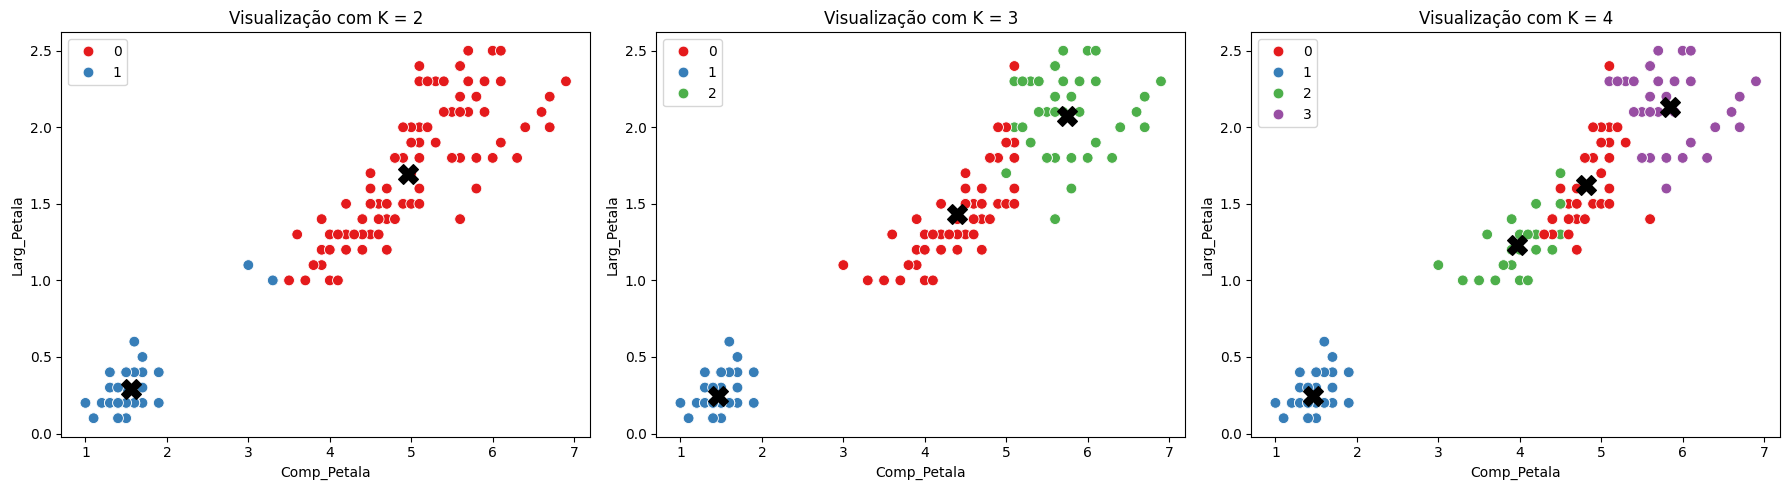

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ks = [2, 3, 4]

for i, k in enumerate(ks):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df)

    sns.scatterplot(ax=axes[i], x=df['Comp_Petala'], y=df['Larg_Petala'],
                    hue=labels, palette='Set1', s=60)

    centroids = kmeans.cluster_centers_
    axes[i].scatter(centroids[:, 2], centroids[:, 3], s=200, c='black', marker='X', label='Centroides')
    axes[i].set_title(f'Visualização com K = {k}')

plt.tight_layout()
plt.show()

In [10]:
from sklearn.metrics import confusion_matrix

final_model = KMeans(n_clusters=3, random_state=42, n_init=10)
pred_labels = final_model.fit_predict(df)

from scipy.stats import mode
labels_corrigidos = np.zeros_like(pred_labels)
for i in range(3):
    mask = (pred_labels == i)
    labels_corrigidos[mask] = mode(iris.target[mask])[0]

print(f"Precisão da Recuperação de Classes: {np.mean(labels_corrigidos == iris.target)*100:.2f}%")

Precisão da Recuperação de Classes: 89.33%
